In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
train_df = pd.read_csv(
    "../data/processed/train_features.csv"
)

exclude_cols = [
    "unit",
    "cycle",
    "RUL",
    "setting_1",
    "setting_2",
    "setting_3"
]

feature_cols = [
    col for col in train_df.columns
    if col not in exclude_cols
]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 112
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'sensor_2_roll_mean_5', 'sensor_3_roll_mean_5', 'sensor_4_roll_mean_5', 'sensor_7_roll_mean_5', 'sensor_8_roll_mean_5', 'sensor_9_roll_mean_5', 'sensor_11_roll_mean_5', 'sensor_12_roll_mean_5', 'sensor_13_roll_mean_5', 'sensor_14_roll_mean_5', 'sensor_15_roll_mean_5', 'sensor_17_roll_mean_5', 'sensor_20_roll_mean_5', 'sensor_21_roll_mean_5', 'sensor_2_roll_mean_10', 'sensor_3_roll_mean_10', 'sensor_4_roll_mean_10', 'sensor_7_roll_mean_10', 'sensor_8_roll_mean_10', 'sensor_9_roll_mean_10', 'sensor_11_roll_mean_10', 'sensor_12_roll_mean_10', 'sensor_13_roll_mean_10', 'sensor_14_roll_mean_10', 'sensor_15_roll_mean_10', 'sensor_17_roll_mean_10', 'sensor_20_roll_mean_10', 'sensor_21_roll_mean_10', 'sensor_2_roll_mean_20', 'sensor_3_roll_mean_20', 'sensor_4_roll_mean_20', 'sensor_7_roll_mean_20

In [3]:
train_df = train_df.sort_values(
    ["unit", "cycle"]
).reset_index(drop=True)
print("Dataset shape:", train_df.shape)
train_df.head()

Dataset shape: (20631, 118)


,unit,cycle,setting_1,setting_2,setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,...,sensor_8_diff,sensor_9_diff,sensor_11_diff,sensor_12_diff,sensor_13_diff,sensor_14_diff,sensor_15_diff,sensor_17_diff,sensor_20_diff,sensor_21_diff
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0000,0.0,0.00,0.0000
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,...,-0.02,-2.12,0.02,0.62,0.05,-7.13,0.0123,0.0,-0.06,0.0046
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,...,0.04,8.87,-0.22,0.14,-0.04,1.74,-0.0140,-2.0,-0.05,-0.0794
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,...,0.03,-3.46,-0.14,0.44,0.05,0.60,-0.0496,2.0,-0.07,0.0297
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,...,-0.05,5.67,0.15,-0.67,-0.04,-0.03,0.0612,1.0,0.02,0.0305


In [4]:
exclude_cols = [
    "unit",
    "cycle",
    "RUL",
    "setting_1",
    "setting_2",
    "setting_3"
]

feature_cols = [
    col for col in train_df.columns
    if col not in exclude_cols
]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 112
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'sensor_2_roll_mean_5', 'sensor_3_roll_mean_5', 'sensor_4_roll_mean_5', 'sensor_7_roll_mean_5', 'sensor_8_roll_mean_5', 'sensor_9_roll_mean_5', 'sensor_11_roll_mean_5', 'sensor_12_roll_mean_5', 'sensor_13_roll_mean_5', 'sensor_14_roll_mean_5', 'sensor_15_roll_mean_5', 'sensor_17_roll_mean_5', 'sensor_20_roll_mean_5', 'sensor_21_roll_mean_5', 'sensor_2_roll_mean_10', 'sensor_3_roll_mean_10', 'sensor_4_roll_mean_10', 'sensor_7_roll_mean_10', 'sensor_8_roll_mean_10', 'sensor_9_roll_mean_10', 'sensor_11_roll_mean_10', 'sensor_12_roll_mean_10', 'sensor_13_roll_mean_10', 'sensor_14_roll_mean_10', 'sensor_15_roll_mean_10', 'sensor_17_roll_mean_10', 'sensor_20_roll_mean_10', 'sensor_21_roll_mean_10', 'sensor_2_roll_mean_20', 'sensor_3_roll_mean_20', 'sensor_4_roll_mean_20', 'sensor_7_roll_mean_20

In [5]:
print("Missing values:", train_df[feature_cols].isnull().sum().sum())

Missing values: 0


In [6]:
print("Missing RUL:", train_df["RUL"].isnull().sum())

Missing RUL: 0


In [7]:
units = train_df["unit"].unique()

print("Number of engines:", len(units))


train_units, val_units = train_test_split(
    units,
    test_size=0.2,
    random_state=42
)

print("Training engines:", len(train_units))
print("Validation engines:", len(val_units))

Number of engines: 100
Training engines: 80
Validation engines: 20


In [8]:
train_data = train_df[
    train_df["unit"].isin(train_units)
].copy()

val_data = train_df[
    train_df["unit"].isin(val_units)
].copy()


print(
    "Overlapping engines:",
    len(set(train_data["unit"]) & set(val_data["unit"]))
)

Overlapping engines: 0


In [9]:
scaler = StandardScaler()

train_data_scaled = train_data.copy()
val_data_scaled = val_data.copy()

train_data_scaled[feature_cols] = scaler.fit_transform(
    train_data[feature_cols]
)

val_data_scaled[feature_cols] = scaler.transform(
    val_data[feature_cols]
)

joblib.dump(
    scaler,
    "../models/gru_feature_scaler.joblib"
)

['../models/gru_feature_scaler.joblib']

In [10]:
sequence_length = 30

def create_sequences(data, feature_cols, sequence_length):
    X = []
    y = []

    for unit in data["unit"].unique():

        unit_data = data[
            data["unit"] == unit
        ].sort_values("cycle")

        features = unit_data[feature_cols].values
        rul = unit_data["RUL"].values

        if len(unit_data) < sequence_length:
            continue

        for i in range(sequence_length - 1, len(unit_data)):
            X.append(
                features[i - sequence_length + 1:i + 1]
            )
            y.append(rul[i])

    return np.array(X), np.array(y)

In [11]:
X_train_seq, y_train_seq = create_sequences(
    train_data_scaled,
    feature_cols,
    sequence_length
)

In [12]:
X_val_seq, y_val_seq = create_sequences(
    val_data_scaled,
    feature_cols,
    sequence_length
)

In [13]:
print("X_train:", X_train_seq.shape)
print("y_train:", y_train_seq.shape)

print("X_val:", X_val_seq.shape)
print("y_val:", y_val_seq.shape)

X_train: (14241, 30, 112)
y_train: (14241,)
X_val: (3490, 30, 112)
y_val: (3490,)


In [14]:
model = Sequential([
    Input(shape=(sequence_length, len(feature_cols))),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 64)                  │          34,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 36,289 (141.75 KB)

 Trainable params: 36,289 (141.75 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [16]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [17]:
history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - loss: 6286.6182 - mae: 58.7254 - val_loss: 1402.3661 - val_mae: 27.6700
Epoch 2/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 1594.6879 - mae: 28.4355 - val_loss: 975.8526 - val_mae: 23.4936
Epoch 3/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 1272.9723 - mae: 24.8235 - val_loss: 897.8658 - val_mae: 21.8249
Epoch 4/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 971.5980 - mae: 21.2201 - val_loss: 816.4283 - val_mae: 19.5982
Epoch 5/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 681.7148 - mae: 17.7321 - val_loss: 844.2686 - val_mae: 20.0033
Epoch 6/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 501.0320 - mae: 15.4375 - val_loss: 810.7184 - val_mae: 19.5666
Epoch 7/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 382.7634 - mae: 13.7717 - val_loss: 885.7253 - val_mae: 20.2962
Epoch 8/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 296.2274 - mae: 12.4233 - val_loss: 799.5023 - val_mae: 19.

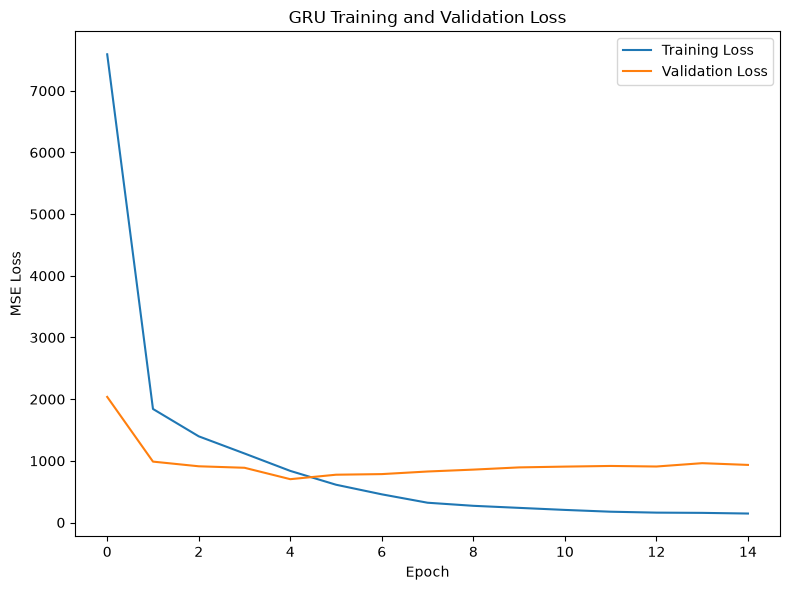

In [57]:
plt.figure(figsize=(8, 6))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GRU Training and Validation Loss")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/figures/feature_engineered/gru/training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

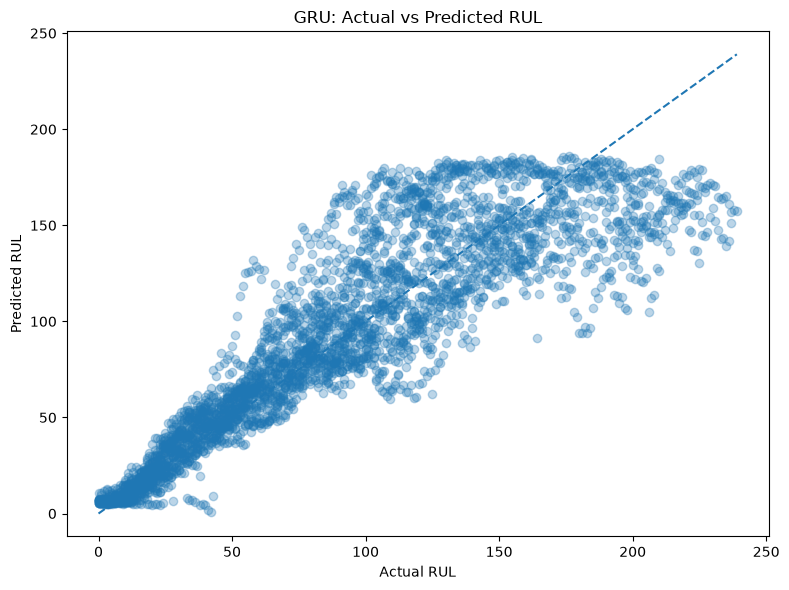

In [60]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_val_seq,
    y_pred,
    alpha=0.3
)

plt.plot(
    [y_val_seq.min(), y_val_seq.max()],
    [y_val_seq.min(), y_val_seq.max()],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("GRU: Actual vs Predicted RUL")

plt.tight_layout()

plt.savefig(
    "../results/figures/feature_engineered/gru/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

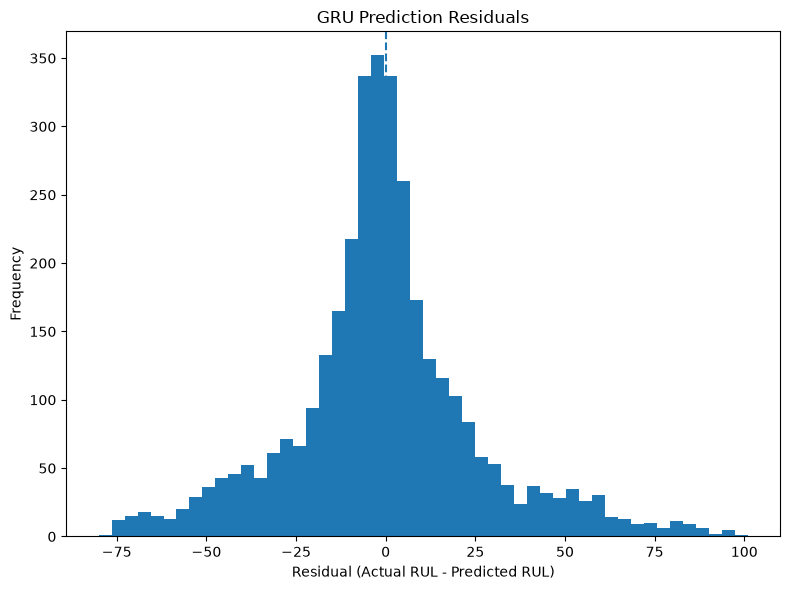

In [61]:
residuals = y_val_seq - y_pred
plt.figure(figsize=(8, 6))

plt.hist(
    residuals,
    bins=50
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual (Actual RUL - Predicted RUL)")
plt.ylabel("Frequency")
plt.title("GRU Prediction Residuals")

plt.tight_layout()

plt.savefig(
    "../results/figures/feature_engineered/gru/residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
y_pred = model.predict(
    X_val_seq
).flatten()

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [19]:
mae = mean_absolute_error(y_val_seq, y_pred)
rmse = np.sqrt(mean_squared_error(y_val_seq, y_pred))
r2 = r2_score(y_val_seq, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")



MAE: 19.2796
RMSE: 28.2755
R²: 0.7643


In [20]:
metrics = pd.DataFrame({
    "model": ["GRU Feature-Engineered"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2]
})

metrics.to_csv(
    "../results/metrics/gru_feature_engineered_metrics.csv",
    index=False
)

In [21]:
model.save(
    "../models/gru_feature_engineered_scaled.keras"
)

In [62]:
model2 = Sequential([
    Input(shape=(sequence_length, len(feature_cols))),
    GRU(128, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

model2.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history = model2.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - loss: 4701.9609 - mae: 49.4468 - val_loss: 1269.7616 - val_mae: 27.4015
Epoch 2/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 1477.2400 - mae: 27.4225 - val_loss: 952.9483 - val_mae: 23.1168
Epoch 3/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 1051.5692 - mae: 22.7014 - val_loss: 829.6567 - val_mae: 21.1106
Epoch 4/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 699.2383 - mae: 18.2667 - val_loss: 847.3264 - val_mae: 20.9629
Epoch 5/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 400.7185 - mae: 13.9801 - val_loss: 962.8330 - val_mae: 21.4188
Epoch 6/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 259.6203 - mae: 11.6503 - val_loss: 938.8500 - val_mae: 21.1169
Epoch 7/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 198.1563 - mae: 10.3996 - val_loss: 861.1304 - val_mae: 20.4924
Epoch 8/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 174.4340 - mae: 9.8406 - val_loss: 994.1036 - val_ma

In [63]:
y_pred2 = model2.predict(
    X_val_seq
).flatten()

110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


In [65]:
mae = mean_absolute_error(y_val_seq, y_pred2)
rmse = np.sqrt(mean_squared_error(y_val_seq, y_pred2))
r2 = r2_score(y_val_seq, y_pred2)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")



MAE: 21.1106
RMSE: 28.8038
R²: 0.7555


In [74]:
model3 = Sequential([
    Input(shape=(sequence_length, len(feature_cols))),

    GRU(64, return_sequences=True),
    Dropout(0.2),

    GRU(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation="relu"),
    Dense(1)
])

model3.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history3 = model3.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - loss: 10636.8262 - mae: 82.7756 - val_loss: 6394.8833 - val_mae: 60.5330
Epoch 2/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 4359.9146 - mae: 44.5239 - val_loss: 1701.0917 - val_mae: 27.3533
Epoch 3/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - loss: 1596.8872 - mae: 24.8152 - val_loss: 778.1923 - val_mae: 19.6713
Epoch 4/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - loss: 931.9730 - mae: 18.7277 - val_loss: 650.5009 - val_mae: 17.8163
Epoch 5/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 649.6188 - mae: 15.9122 - val_loss: 672.3403 - val_mae: 18.2952
Epoch 6/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - loss: 454.1125 - mae: 13.6800 - val_loss: 812.4601 - val_mae: 19.1289
Epoch 7/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 347.3598 - mae: 12.1985 - val_loss: 827.8427 - val_mae: 19.8645
Epoch 8/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - loss: 265.7097 - mae: 10.9811 - val_loss: 746.1342 - val_

In [75]:
y_pred3 = model3.predict(
    X_val_seq
).flatten()

110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


In [76]:
mae = mean_absolute_error(y_val_seq, y_pred3)
rmse = np.sqrt(mean_squared_error(y_val_seq, y_pred3))
r2 = r2_score(y_val_seq, y_pred3)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 17.8163
RMSE: 25.5049
R²: 0.8083


In [69]:
model3.save(
    "../models/gru_stacked_feature_engineered_scaled.keras"
)

In [70]:
metrics3 = pd.DataFrame({
    "model": ["Stacked GRU Feature-Engineered Scaled"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2]
})

metrics.to_csv(
    "../results/metrics/gru_stacked_feature_engineered_scaled_metrics.csv",
    index=False
)

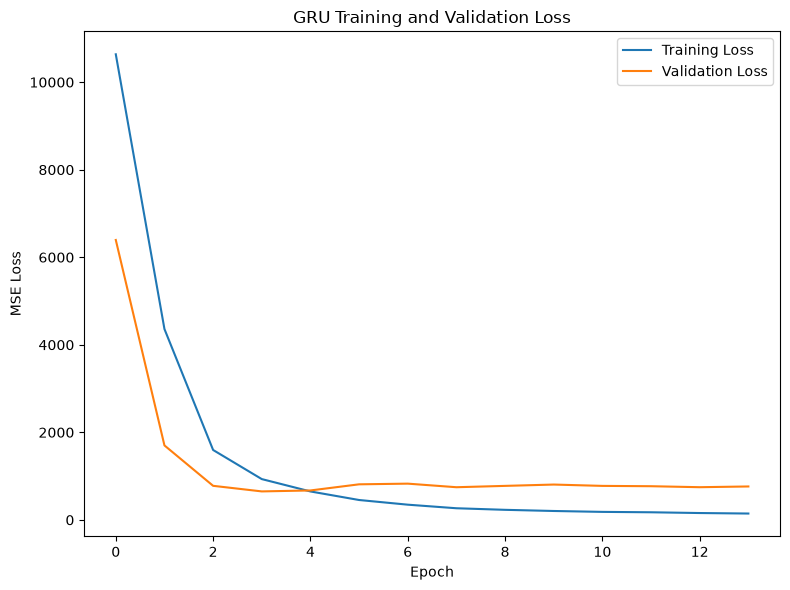

In [77]:
plt.figure(figsize=(8, 6))

plt.plot(history3.history["loss"], label="Training Loss")
plt.plot(history3.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("GRU Training and Validation Loss")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/figures/feature_engineered/gru/training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

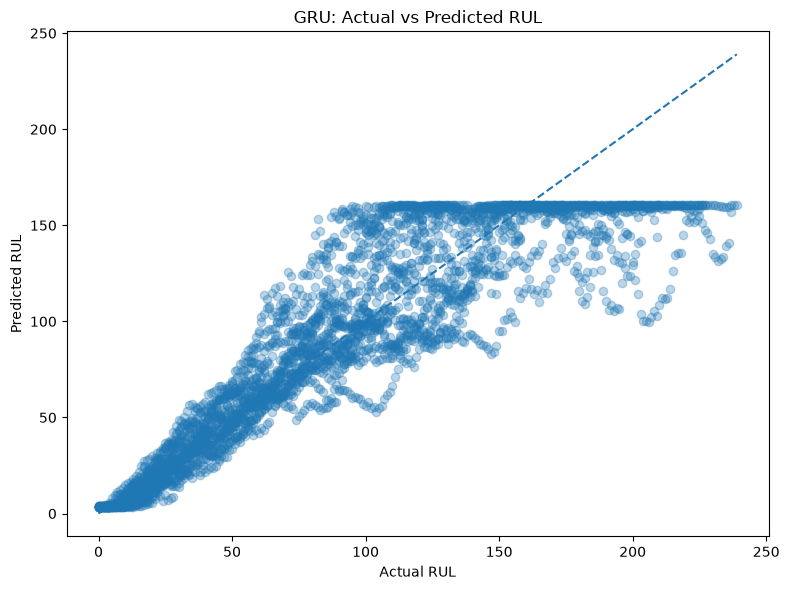

In [78]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_val_seq,
    y_pred3,
    alpha=0.3
)

plt.plot(
    [y_val_seq.min(), y_val_seq.max()],
    [y_val_seq.min(), y_val_seq.max()],
    linestyle="--"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("GRU: Actual vs Predicted RUL")

plt.tight_layout()

plt.savefig(
    "../results/figures/feature_engineered/gru/actual_vs_predicted2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

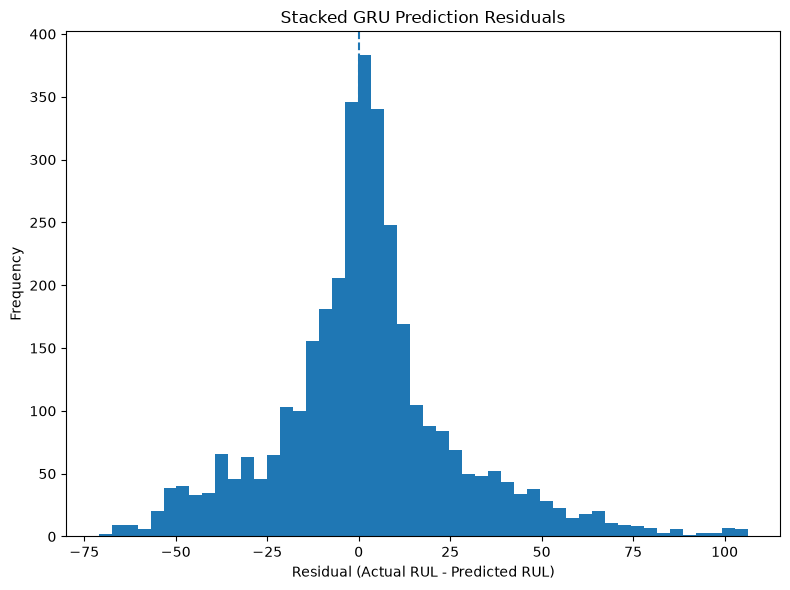

In [79]:
residuals = y_val_seq - y_pred3
plt.figure(figsize=(8, 6))

plt.hist(
    residuals,
    bins=50
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual (Actual RUL - Predicted RUL)")
plt.ylabel("Frequency")
plt.title("Stacked GRU Prediction Residuals")

plt.tight_layout()

plt.savefig(
    "../results/figures/feature_engineered/gru/residual_distribution2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()